### Techniques Used

    Deep Convolutional Neural Network (CNN)

    Data Augmentation to improve generalization

    Batch Normalization for stable training

    Dropout for regularization and overfitting reduction

    EarlyStopping to prevent overfitting
  
    ReduceLROnPlateau for adaptive learning rate

### Model Architecture

#### Custom CNN architecture

Input size: 128 × 128 × 3

#### 5 Convolutional Blocks
  
    Conv2D (32 filters)

    Conv2D (64 filters)

    Conv2D (128 filters)

    Conv2D (256 filters)

    Conv2D (512 filters)

#### Each block contains

    Convolution Layer

    Batch Normalization

    MaxPooling Layer
    
#### Feature Reduction

    GlobalAveragePooling2D

    Fully Connected Layers:

    Dense layer (512 neurons, ReLU)

    Dropout (0.5)

    Dense layer (256 neurons, ReLU)

    Dropout (0.3)

#### Output Layer

    Dense(1) with Sigmoid activation

### Training

    Optimizer: Adam (learning rate = 0.0001)

    Loss Function: Binary Crossentropy

    Metric: Accuracy

#### Callbacks: 

    EarlyStopping

    ReduceLROnPlateau

### Prediction

    The trained model predicts Real vs AI-generated images using the trained CNN model on the validation/test dataset.

### Output

#### The notebook visualizes

    Training vs Validation Accuracy
    Training vs Validation Loss
    Model performance during training

### Goal

    Demonstrate how a deep CNN architecture with data augmentation and regularization techniques can effectively classify Real and AI-generated images.

### Import Libraries

In [20]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset Path Setup

In [21]:
train_dir = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train"
test_dir  = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test"

### Hyperparameters

In [ ]:
batch_size = 128
img_size =128

### Data Augmentation

In [22]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

### Data Generators

In [24]:
 train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size,img_size),   
    batch_size=batch_size,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size,img_size), 
    batch_size=batch_size,
    class_mode='binary'
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


### CNN Model Architecture

In [25]:
model = Sequential()

 
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(img_size,img_size,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D())

 
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

 
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

 
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

 
model.add(Conv2D(512,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

 
model.add(GlobalAveragePooling2D())

 
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,966,785 (7.50 MB)

 Trainable params: 1,964,801 (7.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

### Model Compilation

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Training Callbacks

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

In [29]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

### Model Training

In [30]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30


2026-03-09 14:11:08.597690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 14:11:08.766205: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


336/782 ━━━━━━━━━━━━━━━━━━━━ 4:01 542ms/step - accuracy: 0.7937 - loss: 0.4432

2026-03-09 14:14:17.797846: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-09 14:14:17.945736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


782/782 ━━━━━━━━━━━━━━━━━━━━ 499s 622ms/step - accuracy: 0.8326 - loss: 0.3752 - val_accuracy: 0.9076 - val_loss: 0.2243 - learning_rate: 1.0000e-04
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 542s 693ms/step - accuracy: 0.9175 - loss: 0.2089 - val_accuracy: 0.9129 - val_loss: 0.2163 - learning_rate: 1.0000e-04
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 517s 660ms/step - accuracy: 0.9300 - loss: 0.1758 - val_accuracy: 0.9244 - val_loss: 0.1921 - learning_rate: 1.0000e-04
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 512s 654ms/step - accuracy: 0.9410 - loss: 0.1527 - val_accuracy: 0.8987 - val_loss: 0.2519 - learning_rate: 1.0000e-04
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 530s 677ms/step - accuracy: 0.9455 - loss: 0.1400 - val_accuracy: 0.9492 - val_loss: 0.1275 - learning_rate: 1.0000e-04
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 532s 680ms/step - accuracy: 0.9500 - loss: 0.1280 - val_accuracy: 0.9448 - val_loss: 0.1431 - learning_rate: 1.0000e-04
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 527s 674ms/

### Training Loss Graph

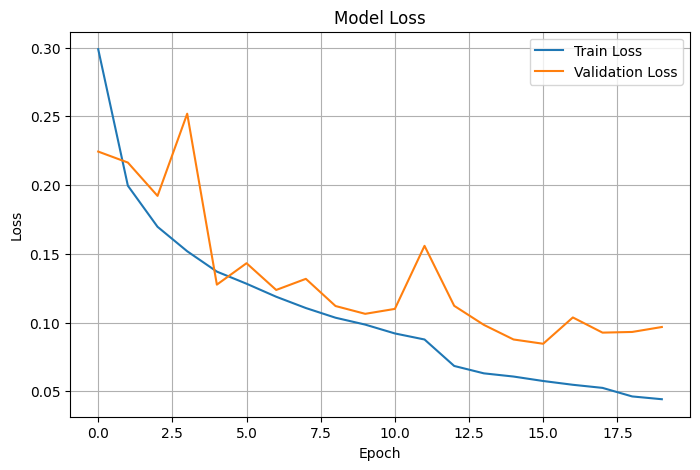

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

### Training Accuracy Graph

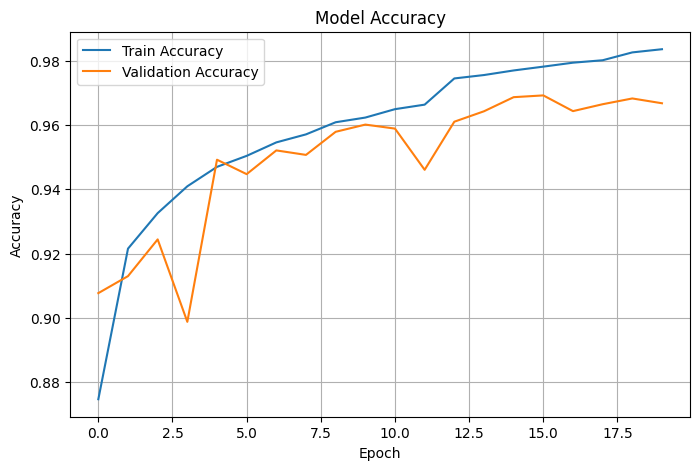

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

### Confusion Matrix

In [57]:
print(validation_generator.class_indices)

{'FAKE': 0, 'REAL': 1}


In [64]:
test_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False   
)

Found 20000 images belonging to 2 classes.


In [65]:
validation_generator.reset()

pred = model.predict(validation_generator)
y_pred = (pred > 0.5).astype(int).reshape(-1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 193ms/step


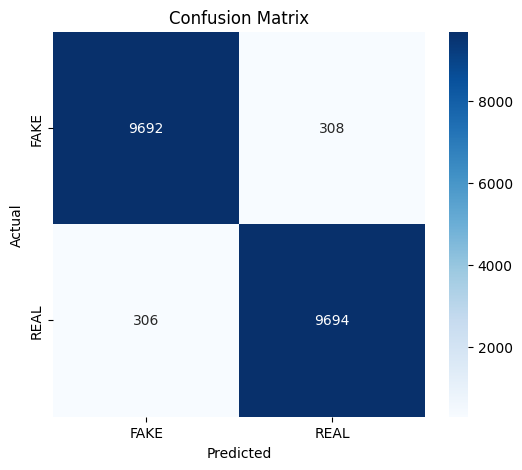

In [68]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["FAKE","REAL"],
    yticklabels=["FAKE","REAL"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [70]:
model.save("output_model.keras")

In [72]:
model.save("/kaggle/working/cifake_model.h5")